# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
%matplotlib inline

In [4]:
train = pd.read_csv('deliveries.csv')
train.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


### Exploratory Data Analysis

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [6]:
d = train.describe()
d

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


C:\Users\pc\AppData\Local\Temp\ipykernel_18256\1536408183.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_wicket',data=train,palette='RdBu_r')


Text(0.5, 1.0, 'Distribusi Wicket')

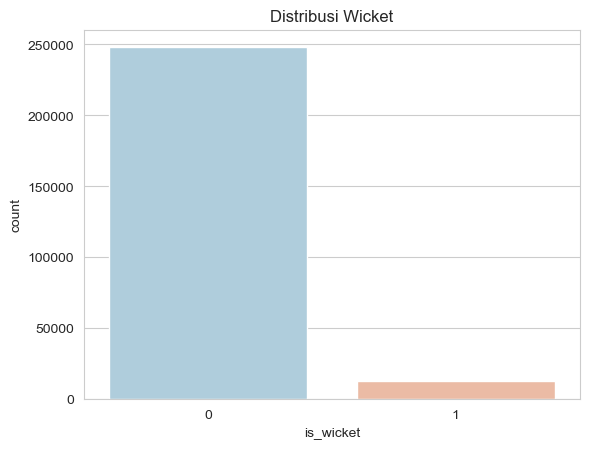

In [8]:
# Cek relative size dari survived dan not survived
sns.countplot(x='is_wicket',data=train,palette='RdBu_r')
plt.title('Distribusi Wicket')

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

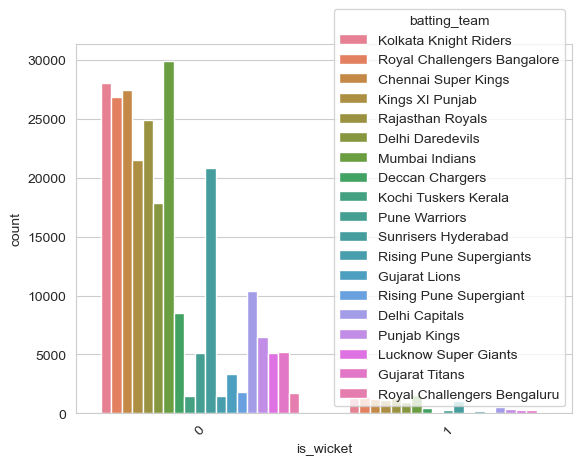

In [10]:
# Survivablity vs sex
sns.countplot(x='is_wicket',hue='batting_team',data=train)
plt.xticks(rotation=45)


<Axes: xlabel='is_wicket', ylabel='count'>

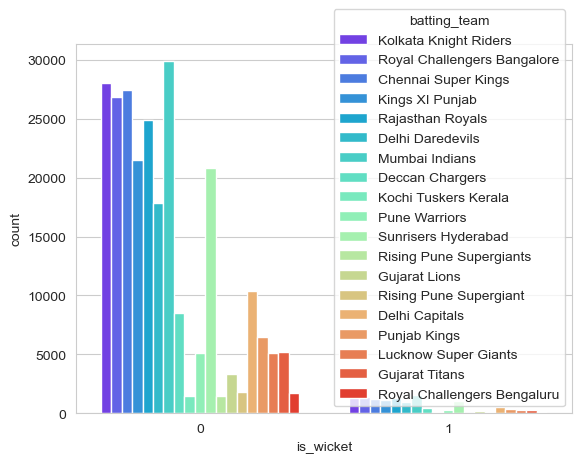

In [14]:
# Survivablity vs passenger class
sns.countplot(x='is_wicket', hue='batting_team', data=train, palette='rainbow')

Text(0.5, 1.0, 'Persentase wicket berdasarkan batting team')

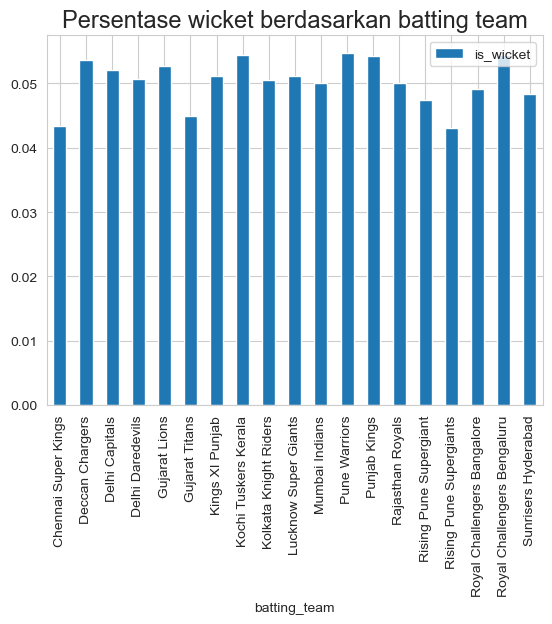

In [16]:
f_class_survived = train.groupby('batting_team')['is_wicket'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived.plot.bar(y='is_wicket')
plt.title("Persentase wicket berdasarkan batting team", fontsize=17)

<Axes: xlabel='is_wicket', ylabel='count'>

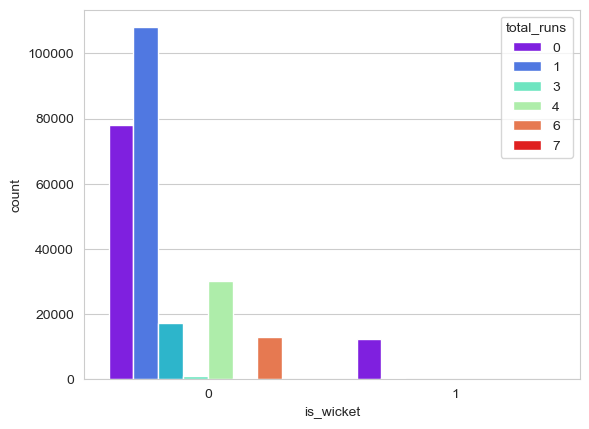

In [18]:
# Survived vs Sibling and Spouses
sns.countplot(x='is_wicket', hue='total_runs', data=train, palette='rainbow')

<Axes: title={'center': 'Histogram Total Runs'}, xlabel='Total Runs', ylabel='Count'>

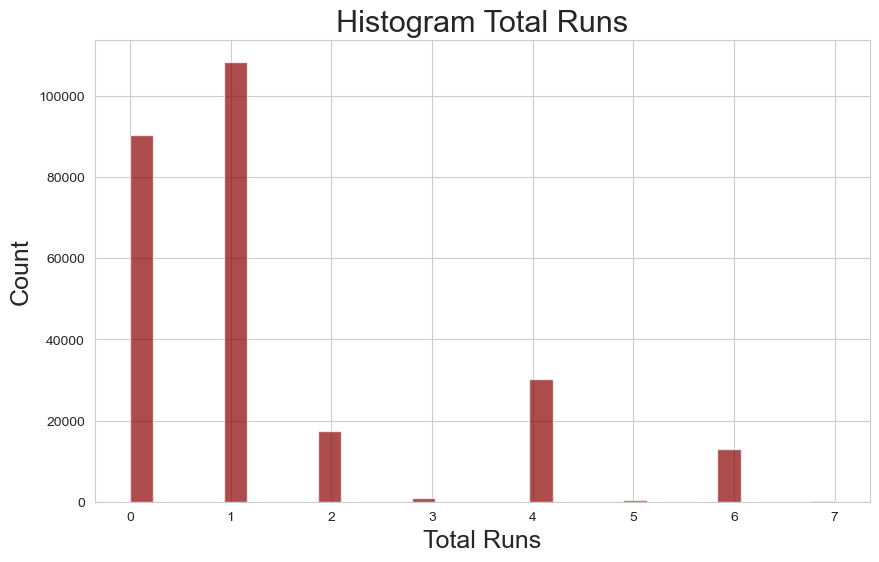

In [22]:
# Cek distribusi dari umur
plt.xlabel("Total Runs",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram Total Runs",fontsize=22)
train['total_runs'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

C:\Users\pc\AppData\Local\Temp\ipykernel_18256\42201121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='batting_team', y='total_runs', data=train, palette='winter')


<Axes: xlabel='Batting Team', ylabel='Total Runs'>

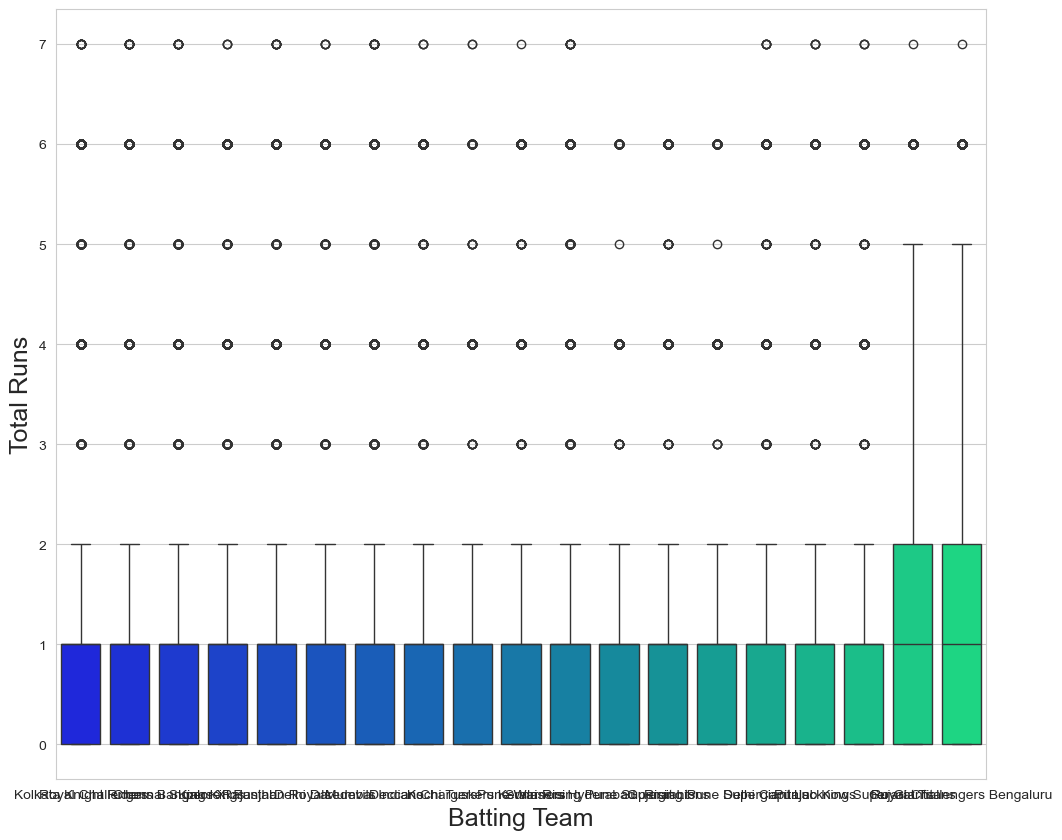

In [24]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Batting Team",fontsize=18)
plt.ylabel("Total Runs",fontsize=18)
sns.boxplot(x='batting_team', y='total_runs', data=train, palette='winter')

Text(0.5, 0, 'Batting Team')

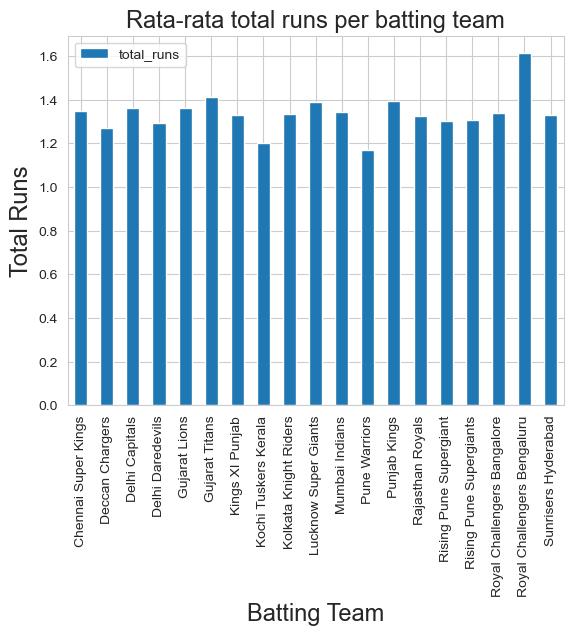

In [25]:
f_class_Age = train.groupby('batting_team')['total_runs'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='total_runs')

plt.title("Rata-rata total runs per batting team", fontsize=17)
plt.ylabel("Total Runs", fontsize=17)
plt.xlabel("Batting Team", fontsize=17)

### Fitur Engineering

In [30]:
a = list(f_class_Age['total_runs'])

def impute_runs(cols):
    total_runs = cols[0]
    over = cols[1]

    if pd.isnull(total_runs):
        return a[int(over)-1]
    else:
        return total_runs

In [32]:
train.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

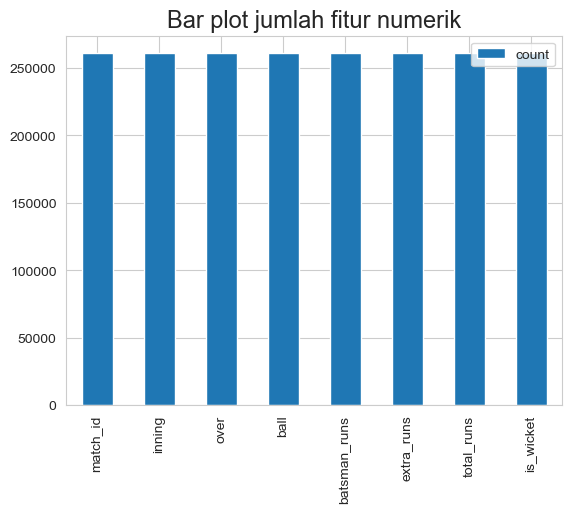

In [33]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [35]:
# drop cabin karena memiliki banyak null value (>50%)
train.dropna(inplace=True)
train.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
6670,336010,1,Kolkata Knight Riders,Royal Challengers Bangalore,8,6,DJ Hussey,A Kumble,T Taibu,0,1,1,legbyes,1,DJ Hussey,run out,DW Steyn
9022,336020,1,Delhi Daredevils,Deccan Chargers,15,2,G Gambhir,PP Ojha,S Dhawan,0,1,1,wides,1,G Gambhir,stumped,AC Gilchrist
21707,392217,2,Chennai Super Kings,Rajasthan Royals,16,6,ML Hayden,SK Warne,S Badrinath,0,1,1,wides,1,ML Hayden,stumped,NV Ojha
21927,392218,2,Royal Challengers Bangalore,Mumbai Indians,13,2,RE van der Merwe,Harbhajan Singh,MV Boucher,0,1,1,wides,1,RE van der Merwe,stumped,YV Takawale
22808,392222,1,Kings XI Punjab,Mumbai Indians,17,6,K Goel,SL Malinga,PP Chawla,0,1,1,wides,1,PP Chawla,run out,YV Takawale


In [37]:
# Drop semua kolom yang tidak penting
train.drop(columns=['match_id','umpire1','umpire2'], errors='ignore', inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### Training

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('is_wicket', axis=1),
    train['is_wicket'],
    test_size=0.30,
    random_state=42
)

In [47]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (39, 15)
Test shape: (17, 15)


# **KNN**

In [51]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [53]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.71
Confusion Matrix:
[[136  31]
 [ 47  53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.78       167
           1       0.63      0.53      0.58       100

    accuracy                           0.71       267
   macro avg       0.69      0.67      0.68       267
weighted avg       0.70      0.71      0.70       267



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [54]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[17]]
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        17

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### jika ingin mencoba semua parameter

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...                 1.0   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...                 1.0   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...                 1.0   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...                 1.0   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...                 1.0   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...                 1.0   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...                 1.0   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...                 1.0   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...                 1.0   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...                 1.0   
10  {'metric': 'manhattan', 'n_neighbors

In [57]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [58]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [59]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        17

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17

Confusion Matrix:
[[17]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [61]:
import pandas as pd

# buat data kosong sesuai jumlah fitur model
new_data = pd.DataFrame([[0]*len(X_train.columns)], columns=X_train.columns)

# isi contoh nilai
new_data['over'] = 5
new_data['ball'] = 3
new_data['total_runs'] = 1

# contoh encoding team (WAJIB sesuai nama kolom di X_train)
new_data['batting_team_Chennai Super Kings'] = 1
new_data['bowling_team_Mumbai Indians'] = 1

# prediksi
prediction = best_model.predict(new_data)

print("Prediksi (0 = Tidak Wicket, 1 = Wicket):", prediction[0])

Prediksi (0 = Tidak Wicket, 1 = Wicket): 1
